<a href="https://colab.research.google.com/github/trumanPHYS/Physics-Data-Plots-1/blob/main/SPRINGLab6Plot.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

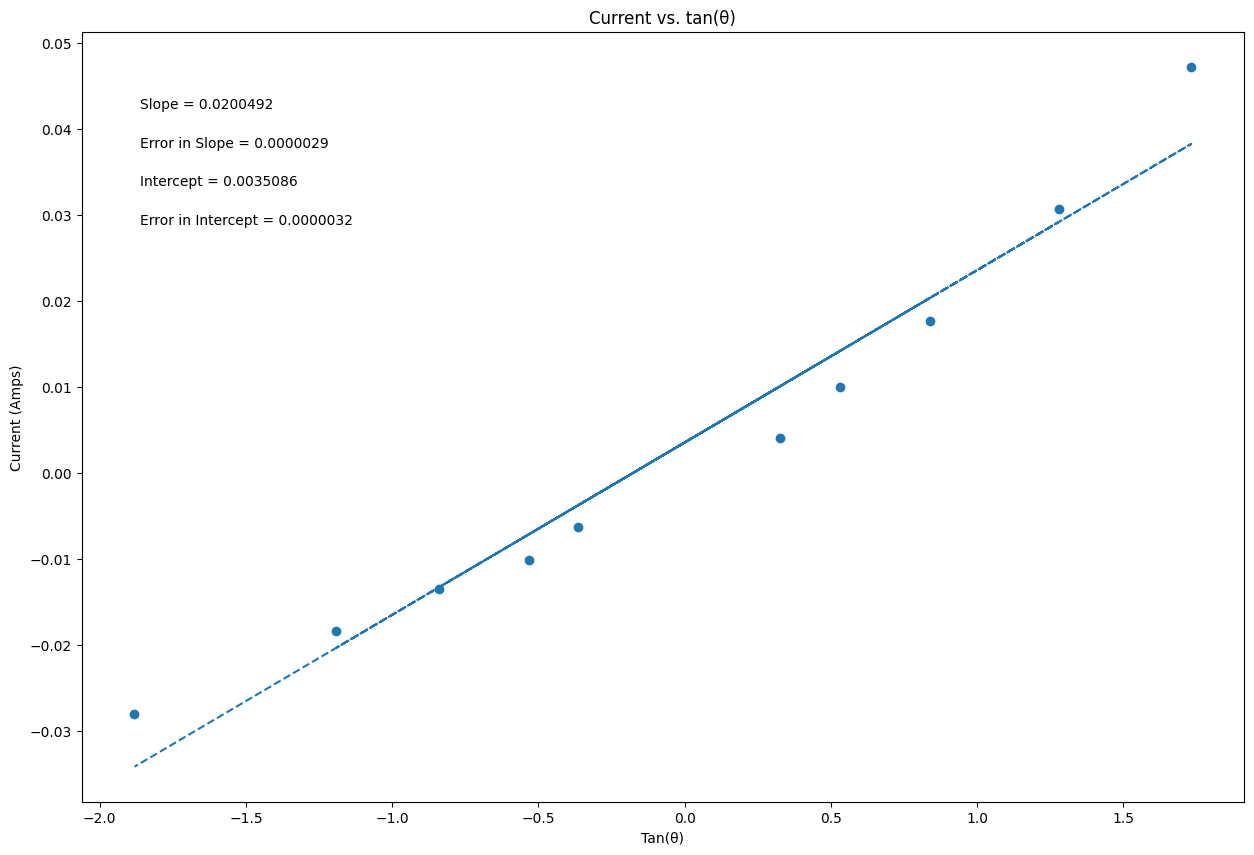

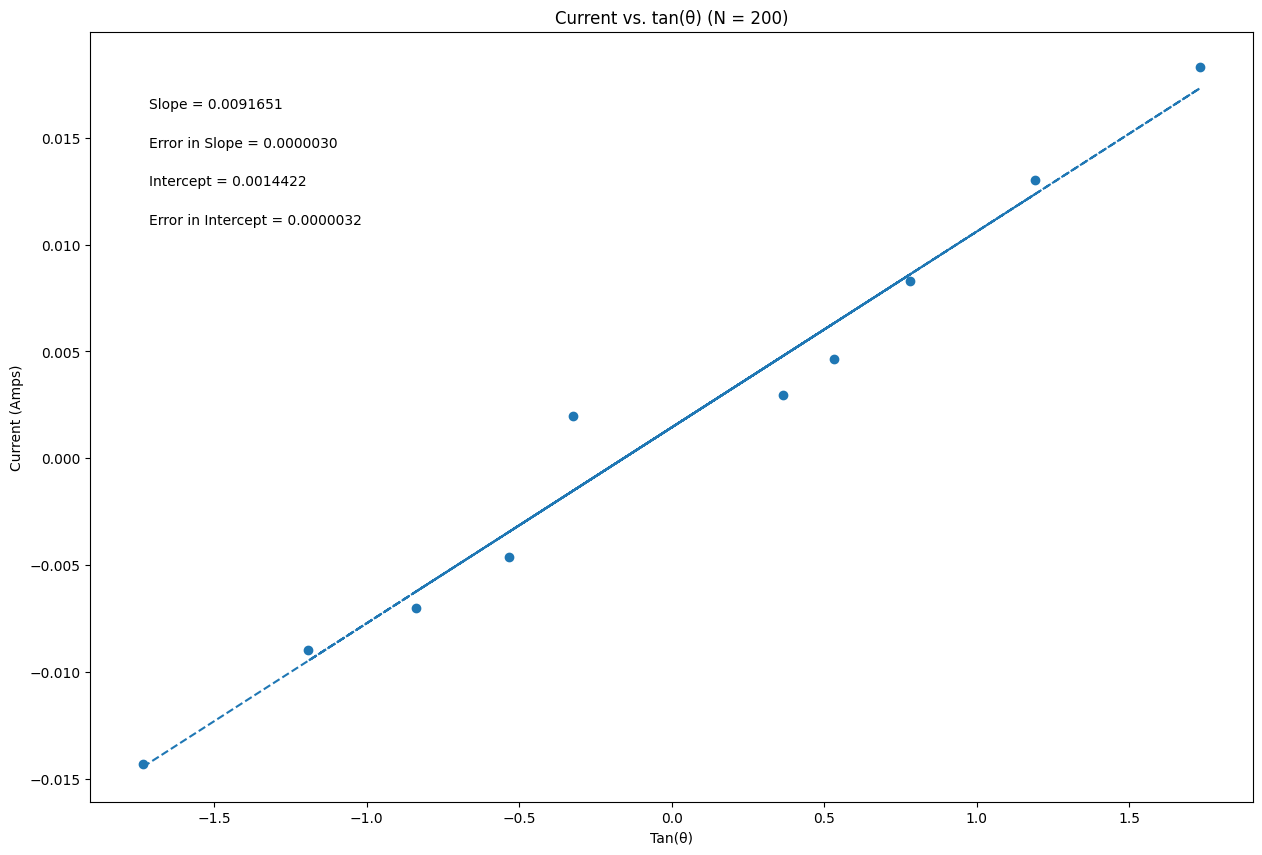

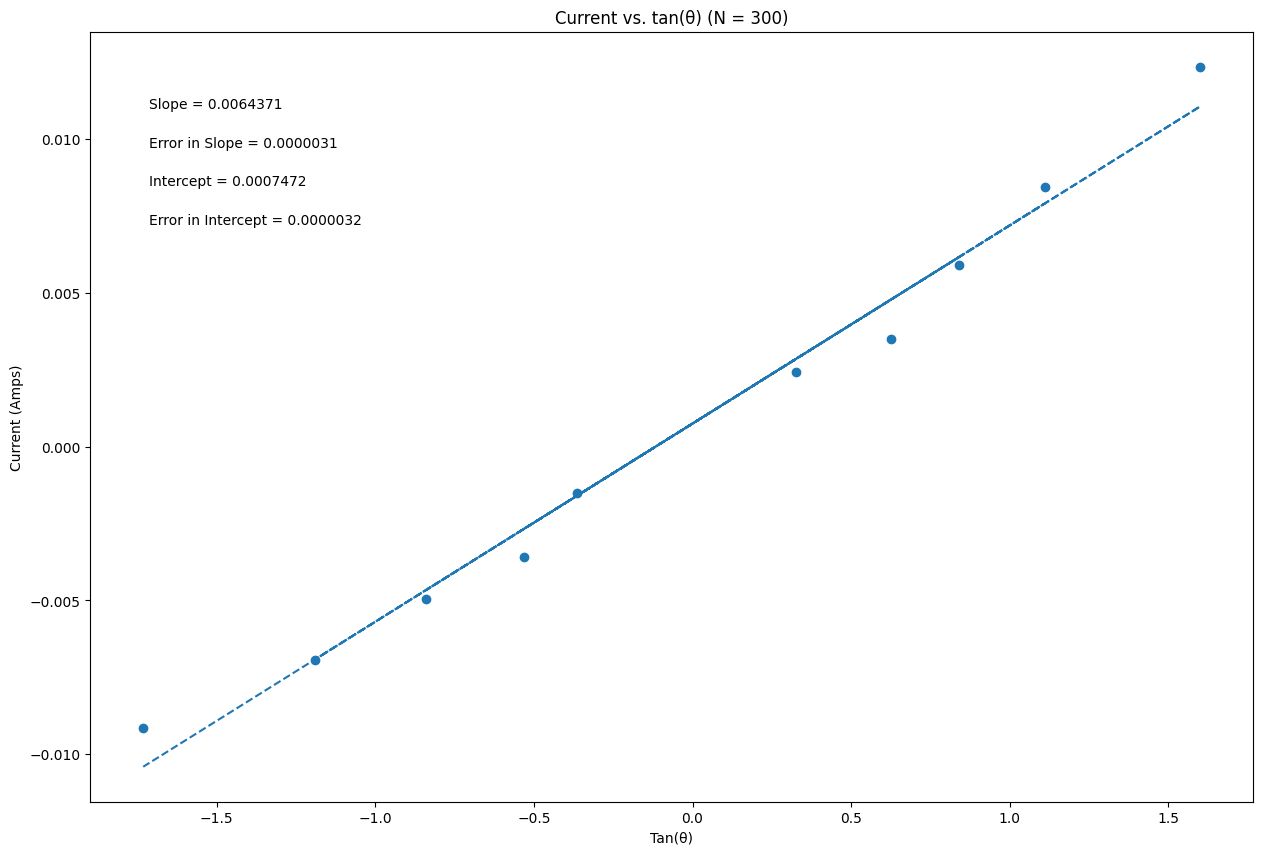

In [2]:
# PHSX 216 & 218 plotting code
# Brianna Beller
# Updated September 2023

%matplotlib inline
from __future__ import division
import numpy as np
import matplotlib.pyplot as plt

# ---------------- DATA ---------------- #

x1 = np.array([0.324919696, -0.363970234, 0.531709432, -0.531709432, 0.839099631, -0.839099631, 1.279941632, -1.191753593, 1.732050808, -1.880726465])
y1 = np.array([0.00408, -0.00635, 0.01001, -0.01015, 0.01765, -0.0135, 0.0307, -0.01845, 0.0472, -0.0281])
dy1 = np.array([0.00001]*10)

x2 = np.array([0.363970234, -0.324919696, 0.531709432, -0.531709432, 0.781285627, -0.839099631, 1.191753593, -1.191753593, 1.732050808, -1.732050808])
y2 = np.array([0.00295, 0.00197, 0.00463, -0.00463, 0.0083, -0.00702, 0.01301, -0.00897, 0.01831, -0.0143])
dy2 = np.array([0.00001]*10)

x3 = np.array([0.324919696, -0.363970234, 0.624869352, -0.531709432, 0.839099631, -0.839099631, 1.110612515, -1.191753593, 1.600334529, -1.732050808])
y3 = np.array([0.00243, -0.00152, 0.00348, -0.0036, 0.0059, -0.00495, 0.00843, -0.00692, 0.01233, -0.00913])
dy3 = np.array([0.00001]*10)

# ---------------- FUNCTIONS ---------------- #

def Delta(x, dy):
    D = (sum(1/dy**2))*(sum(x**2/dy**2))-(sum(x/dy**2))**2
    return D

def LLSFD2(x, y, dy, b, m):
    return sum(((y - (b + m*x))/dy)**2)

def plot_data(x, y, dy, title):
    b, m = np.polynomial.polynomial.polyfit(x, y, 1, w=dy)
    fit = b + m*x

    D = Delta(x, dy)
    dm = np.sqrt((1/D) * sum(1/dy**2))
    db = np.sqrt((1/D) * sum(x**2/dy**2))
    N = LLSFD2(x, y, dy, b, m)

    plt.figure(figsize=(15,10))
    plt.plot(x, fit, linestyle='--')
    plt.scatter(x, y)
    plt.errorbar(x, y, yerr=dy, fmt="none")

    plt.xlabel("Tan(θ)")
    plt.ylabel("Current (Amps)")
    plt.title(title)

    xpos = 0.05
    ypos = [0.9, 0.85, 0.8, 0.75]

    plt.annotate(f"Slope = {m:.7f}", (xpos, ypos[0]), xycoords='axes fraction')
    plt.annotate(f"Error in Slope = {dm:.7f}", (xpos, ypos[1]), xycoords='axes fraction')
    plt.annotate(f"Intercept = {b:.7f}", (xpos, ypos[2]), xycoords='axes fraction')
    plt.annotate(f"Error in Intercept = {db:.7f}", (xpos, ypos[3]), xycoords='axes fraction')

    plt.show()

# ---------------- PLOTS ---------------- #

plot_data(x1, y1, dy1, "Current vs. tan(θ)")
plot_data(x2, y2, dy2, "Current vs. tan(θ) (N = 200)")
plot_data(x3, y3, dy3, "Current vs. tan(θ) (N = 300)")